# Fitting Data 


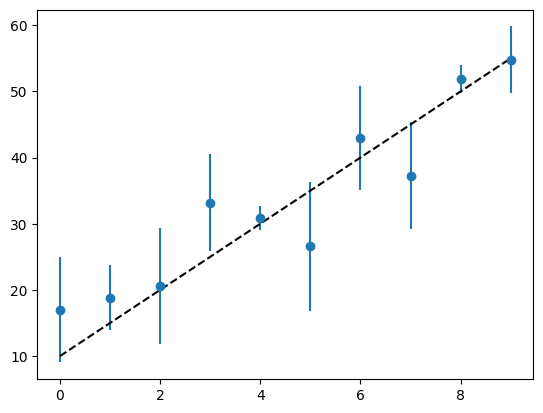

In [3]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
seed = 42
rng = np.random.default_rng(seed)

# Define the true value of the parameters
x_0 = 10.0
v_0 = 5.0 

# Let's suppose we have measurements every second
t_obs = np.arange(0, 10, 1)
xoft_true = x_0 + v_0 * t_obs
sigma_x = rng.uniform(1.0, 10.0, len(t_obs))

# Generate Gaussian deviates for mu=0 and sigma=1
gauss_dev =rng.standard_normal(len(t_obs))
xoft = xoft_true + sigma_x * gauss_dev

# Make a plot of the data with error bars
plt.errorbar(t_obs, xoft, yerr=sigma_x, fmt='o')
plt.plot(t_obs, xoft_true, 'k--')

In [4]:
from scipy import stats

# Define the likelihood function
def log_likelihood(v_0, x_obs, sigma_x, x_0, t_obs):
    
    data_min_model = x_obs - (x_0 + v_0 * t_obs)
    lnL_vec = stats.norm.logpdf(data_min_model, loc=x_obs, scale=sigma_x)
    return np.sum(lnL_vec)

# Plot the likelihood as a function of v_0
v_0_values = np.linspace(0, 10, 100)



